### Project 1 - 
# Identification of geographical origin og tobacco leaves using NIR spectroscopy
**Project goal**: Develop a classification model that predicts the country of origin for tobacco leaves from
NIR spectra

## Part 1 - Exploratory data analysis and preprocessing

Perform an exploratory data analysis, for instance, by using Principal Component Analysis (PCA).
Are there outliers or missing data? Investigate and evaluate the impact of preprocessing using, for
instance, Multiplicative Scatter Correction (MSC), Standard Normal Variate (SNV), normalisation,
and/or derivatives to remove baseline shifts and scattering effects.

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

### 1.1 Read and prepare the data:
In this section, the dataset is loaded and organised for later exploratory analysis and classification.  
To simplify the classification problem, samples from Argentina, Tanzania, and Zambia are merged into one combined class: **Argentina/Tanzania/Zambia**.

The metadata columns are separated from the spectral variables, and the wavelength column names are converted to numerical values.  
This gives a feature matrix \(X\) containing the NIR spectra and a label vector containing the country of origin.

In [3]:
# load the full NIR dataset
nir_df = pd.read_csv("tobacco-nir-all.csv") 

# lump Argentina, Tanzania, and Zambia into one combined class
nir_df["Country"] = nir_df["Country"].replace( 
    {"Argentina": "Argentina/Tanzania/Zambia",
     "Tanzania":  "Argentina/Tanzania/Zambia",
     "Zambia":    "Argentina/Tanzania/Zambia"}
)

# check the class distribution after regroupong
print(nir_df["Country"].value_counts()) # expect 4 categories
# latex version for for report:
# counts = nir_df["Country"].value_counts().reset_index()
# counts.columns = ["Country", "Count"]
# print(counts.to_latex(index=False))

nir_df.head()

Country
Brazil                       136
Zimbabwe                     128
USA                           45
Argentina/Tanzania/Zambia     38
Name: count, dtype: int64


,Sample ID,Planting year,Country,10001.0283203125,9997.17138687565,9993.31445343881,9989.45752000196,9985.60058656511,9981.74365312826,9977.88671969142,...,4034.35229350975,4030.4953600729,4026.63842663606,4022.78149319921,4018.92455976236,4015.06762632551,4011.21069288867,4007.35375945182,4003.49682601497,3999.63989257813
0,1,2021,Argentina/Tanzania/Zambia,0.292623,0.292518,0.292467,0.292411,0.292361,0.292286,0.292234,...,0.677369,0.679197,0.680607,0.681998,0.682849,0.683569,0.683807,0.683901,0.683700,0.683342
1,2,2020,Argentina/Tanzania/Zambia,0.286529,0.286403,0.286367,0.286338,0.286218,0.286121,0.286069,...,0.694849,0.696874,0.698492,0.699980,0.700895,0.701691,0.701907,0.702025,0.701868,0.701515
2,3,2021,Argentina/Tanzania/Zambia,0.286912,0.286834,0.286778,0.286690,0.286588,0.286586,0.286552,...,0.718212,0.720416,0.722157,0.723796,0.724855,0.725728,0.725948,0.726065,0.725868,0.725509
3,4,2021,Argentina/Tanzania/Zambia,0.286566,0.286488,0.286430,0.286442,0.286410,0.286297,0.286200,...,0.701819,0.704060,0.705852,0.707488,0.708545,0.709455,0.709673,0.709795,0.709679,0.709305
4,5,2020,Argentina/Tanzania/Zambia,0.298664,0.298492,0.298369,0.298201,0.298110,0.298050,0.297940,...,0.696671,0.698722,0.700268,0.701732,0.702669,0.703413,0.703604,0.703680,0.703385,0.702902


In [4]:
# Define metadaa columns that are not part of the spectral matrix
metadata = ["Sample ID", "Planting year", "Country"] 

# Isolate the spectral column names
wavelength_cols = [col for col in nir_df.columns if col not in metadata] 

# Convert wavelength labels from strings to numeric values
wavelengths = np.array([float(col) for col in wavelength_cols]) 

# Create the spectral feature matrix X
X = nir_df[wavelength_cols].to_numpy() # all spectra as matrix

# Store the country labels
countries = nir_df["Country"] 

# Get the unique country classes
country_names = nir_df["Country"].unique()

# OPrint basic dimensions for verification
print(f"Number of spectral points: {len(wavelengths)}")
print(f"Shape of feature matrix X: {X.shape}")
print(f"Geographical origins identified: {country_names}")

Number of spectral points: 1557
Shape of feature matrix X: (347, 1557)
Geographical origins identified: ['Argentina/Tanzania/Zambia' 'Brazil' 'Zimbabwe' 'USA']


### 1.2 Define functions to plot the NIR spectra and run and plot scores from PCA
This section defines helper functions for visualising the spectral data and exploring class structure with Principal Component Analysis (PCA).  
These plotting functions will later be used for both the raw spectra and the preprocessed spectra.

In [5]:
# Create one color per country
palette = sns.color_palette("colorblind", 
                            n_colors=len(country_names))

# Store the mapping between country names and colors
country_color_map = dict(zip(country_names, palette))

palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

**Function to plot the NIR spectra**

In [6]:
def plot_nir_spectra(X, wavelengths, labels, colormap, ax, title="NIR spectra", show_legend=True):
    """
    Plots NIR spectra on a provided axes object, grouped by geographical origin.
    
    Args:
        X (np.ndarray): Spectral data matrix
        wavelengths (np.ndarray): Numerical array representing the x-axis values
        labels (pd.Series): Full list of country labels for each sample
        colormap (dict): Dictionary mapping country/origin names to specific colors
        ax (matplotlib.axes.Axes): The axes object where the spectra will be plotted
        title (str): The title to display on the plot. Defaults to "NIR spectra".
        show_legend (bool): Whether to display the legend. Defaults to True.
    """
    for country, color in colormap.items():
        mask = labels == country
        subset = X[mask]

        for i, spectrum in enumerate(subset):
            ax.plot(
                wavelengths,
                spectrum,
                color=color,
                alpha=0.3,
                label=country if i == 0 else None
            )

    ax.set_xlabel("Wavelength (cm$^{-1}$)")
    ax.set_ylabel("Absorbance")
    ax.set_title(title)

    if show_legend:
        ax.legend()

**Function to run PCA**

In [7]:
from sklearn.decomposition import PCA

def run_pca(X, n_components=5):
    """
    Run Principal Component Analysis (PCA) on a spectral data matrix.

    Args
        X : numpy.ndarray
            Spectral data matrix with shape (n_samples, n_variables).
        n_components : int, default=5
            Number of principal components to calculate.

    Returns
        scores : numpy.ndarray
            PCA score matrix with shape (n_samples, n_components).
        var_exp : numpy.ndarray
            Explained variance (%) for each principal component.
        pca : sklearn.decomposition.PCA
            Fitted PCA model object.
    """
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)
    var_exp = pca.explained_variance_ratio_ * 100

    return scores, var_exp, pca

In [11]:
import matplotlib.patches as patches
def plot_pca_scores(scores, varexp, labels, colormap, ax, pcs=(1, 2),
                    ellipses=True, title="PCA Score Plot", show_legend=True):

    idx1, idx2 = pcs[0] - 1, pcs[1] - 1
    unique_labels = np.unique(labels)

    for label in unique_labels:
        color = colormap.get(label, "gray")
        mask = labels == label
        group_scores = scores[mask][:, [idx1, idx2]]

        ax.scatter(
            group_scores[:, 0], group_scores[:, 1],
            color=color, label=label, alpha=0.7,
            edgecolors="white", linewidth=0.5
        )

        if ellipses and len(group_scores) > 2:
            mean = np.mean(group_scores, axis=0)
            cov = np.cov(group_scores, rowvar=False)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            width, height = 2 * np.sqrt(4.605 * vals)

            ell = patches.Ellipse(
                xy=mean, width=width, height=height, angle=theta,
                edgecolor=color, facecolor=color, alpha=0.15
            )
            ax.add_patch(ell)

    ax.set_xlabel(f"PC{pcs[0]} ({varexp[idx1]:.1f}%)")
    ax.set_ylabel(f"PC{pcs[1]} ({varexp[idx2]:.1f}%)")
    ax.set_title(title)

    if show_legend:
        ax.legend(loc="upper right")

    sns.despine(ax=ax)

### 1.3 Evaluate the raw data
The raw data is evaluated using visual inspection of the NIR spectra and PCA scores plot.

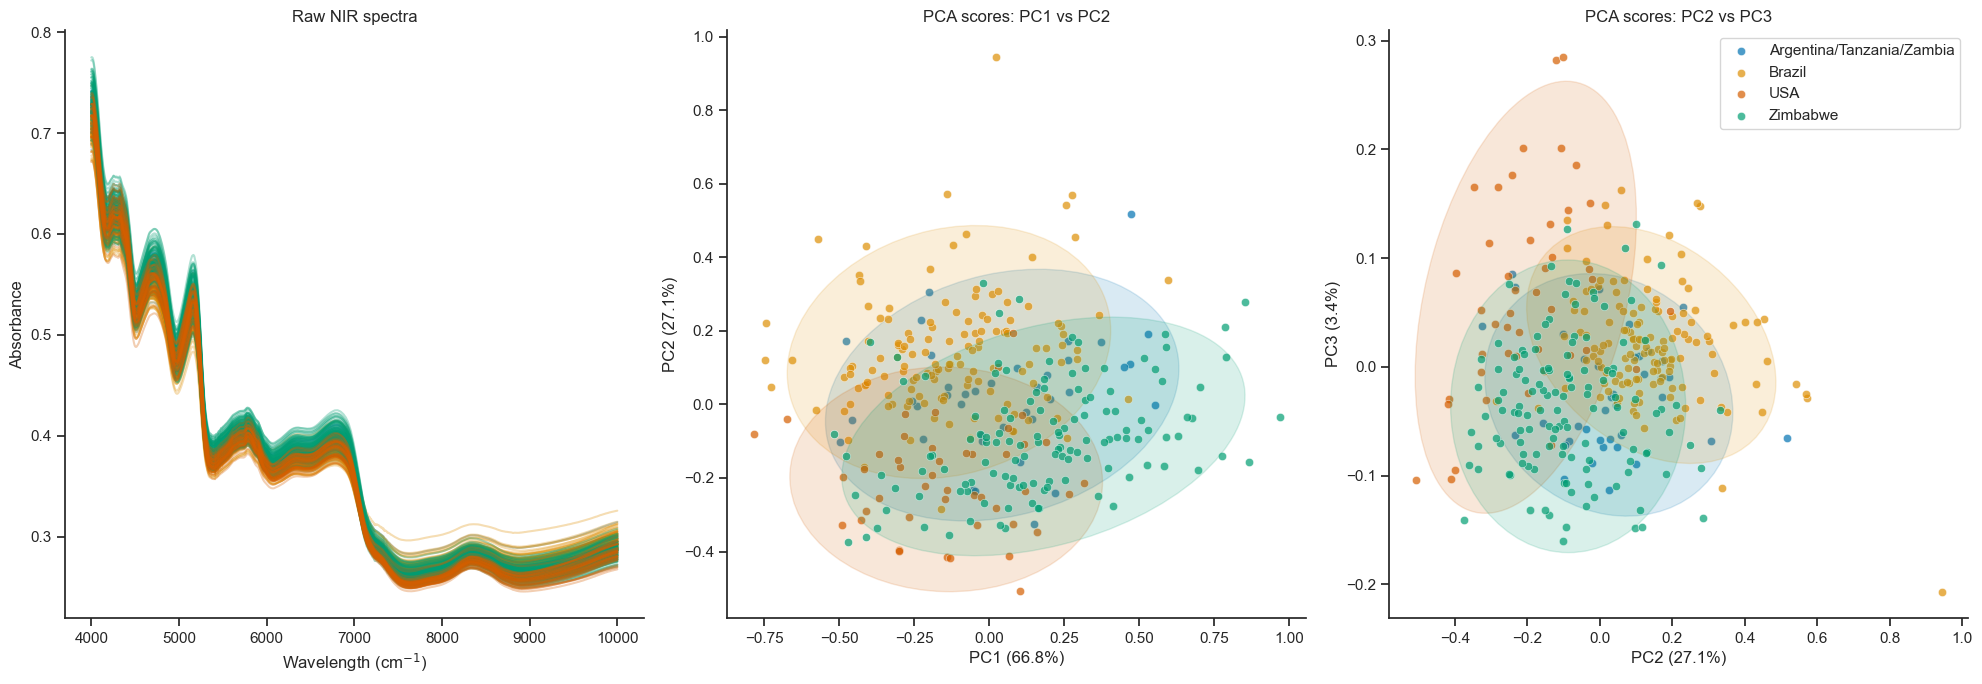

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Raw spectra
plot_nir_spectra(
    X, wavelengths, countries, country_color_map,
    ax=axes[0],
    title="Raw NIR spectra",
    show_legend=False
)

# PCA
scores, varpca, pca = run_pca(X)

plot_pca_scores(
    scores, varpca, countries, country_color_map,
    ax=axes[1],
    pcs=(1, 2),
    ellipses=True,
    title="PCA scores: PC1 vs PC2",
    show_legend=False
)

plot_pca_scores(
    scores, varpca, countries, country_color_map,
    ax=axes[2],
    pcs=(2, 3),
    ellipses=True,
    title="PCA scores: PC2 vs PC3"
)

sns.despine()
plt.tight_layout()
plt.show()

### Outliers / missing data?

See some outliers in both NIR and PCA scores plot. For example, in NIR can see one of the Brazil spectra seems to be shifted up, in region 7000 - 10 000. Can also see a Brazil outlier in PC2. As it looks like it is shifted up in NIR, it might be baseline? So will do preprocessing of the data before evt. dealing with outliers.

In [13]:
# Check if there are any missing values in the entire matrix
missing_count = nir_df.isnull().sum().sum()
missing_count

# check if same number of columns?

np.int64(0)

**Method to check for outliers**

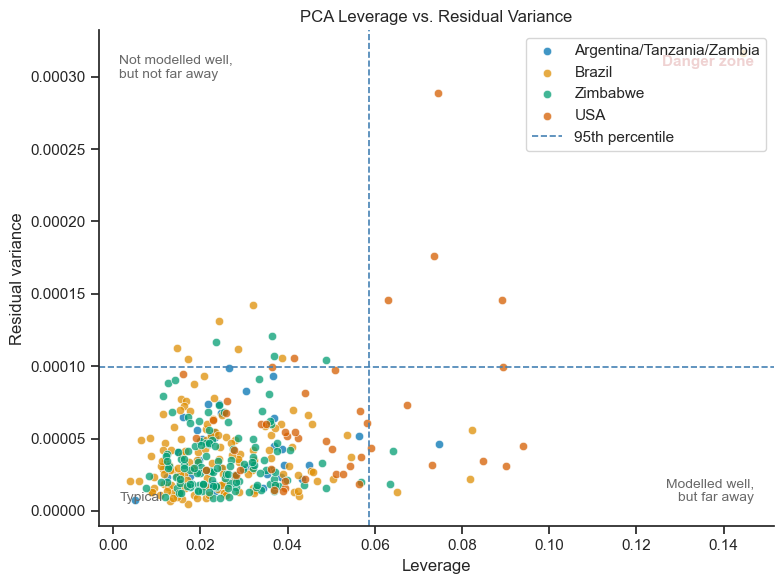

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_leverage_residuals(
    X,
    labels,
    color_map,
    ax,
    PCA_components=10,
    title="Leverage vs. Residual Variance"
):
    """
    PCA outlier screening plot based on:
    - Leverage: diagonal of H = T (T^T T)^(-1) T^T
    - Residual variance: sum of squared residuals from E = X - X_hat

    Parameters
    ----------
    X : np.ndarray
        Data matrix of shape (n_samples, n_features).
    labels : array-like
        Label for each sample, same length as n_samples.
    color_map : dict
        Mapping from label name to color.
    ax : matplotlib.axes.Axes
        Axis to plot on.
    PCA_components : int, default=10
        Number of PCA components.
    title : str
        Plot title.
    """

    X = np.asarray(X)
    labels = np.asarray(labels)

    n_samples, n_features = X.shape
    n_comp = min(PCA_components, n_samples - 1, n_features)

    pca = PCA(n_components=n_comp)
    T = pca.fit_transform(X)                 # scores
    X_hat = pca.inverse_transform(T)         # reconstructed X from PCA model
    E = X - X_hat                            # residual matrix

    # Residual variance / residual sum of squares per sample
    residual_variance = np.sum(E**2, axis=1)

    # Leverage from hat matrix diagonal: H = T (T^T T)^(-1) T^T
    TT_inv = np.linalg.pinv(T.T @ T)
    H = T @ TT_inv @ T.T
    leverage = np.diag(H)

    # 95th percentile thresholds
    lev_threshold = np.percentile(leverage, 95)
    res_threshold = np.percentile(residual_variance, 95)

    # Plot each group
    for group, color in color_map.items():
        mask = labels == group
        ax.scatter(
            leverage[mask],
            residual_variance[mask],
            color=color,
            label=group,
            alpha=0.75,
            edgecolors="white",
            linewidth=0.5
        )

    # Threshold lines
    ax.axvline(
        lev_threshold,
        color="steelblue",
        linestyle="--",
        linewidth=1.2,
        label="95th percentile"
    )
    ax.axhline(
        res_threshold,
        color="steelblue",
        linestyle="--",
        linewidth=1.2
    )

    # Optional quadrant labels
    ax.text(
        0.03, 0.05,
        "Typical",
        transform=ax.transAxes,
        fontsize=10,
        color="dimgray"
    )
    ax.text(
        0.97, 0.05,
        "Modelled well,\nbut far away",
        transform=ax.transAxes,
        ha="right",
        fontsize=10,
        color="dimgray"
    )
    ax.text(
        0.03, 0.95,
        "Not modelled well,\nbut not far away",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        color="dimgray"
    )
    ax.text(
        0.97, 0.95,
        "Danger zone",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        color="firebrick",
        fontweight="bold"
    )

    ax.set_xlabel("Leverage")
    ax.set_ylabel("Residual variance")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=True)

    return {
        "leverage": leverage,
        "residual_variance": residual_variance,
        "lev_threshold": lev_threshold,
        "res_threshold": res_threshold,
        "pca_model": pca
    }


# Example usage
fig, ax = plt.subplots(figsize=(8, 6))

results = plot_pca_leverage_residuals(
    X=X,
    labels=countries,
    color_map=country_color_map,
    ax=ax,
    PCA_components=10,
    title="PCA Leverage vs. Residual Variance"
)

plt.tight_layout()
sns.despine()
plt.show()

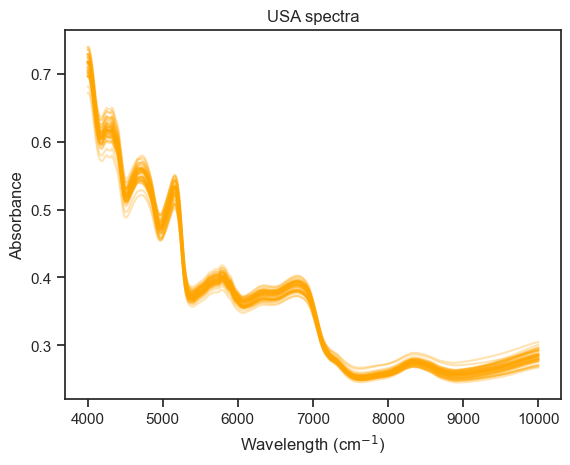

In [17]:
# Inspect USA spectra
X_usa = nir_df[nir_df["Country"] == "USA"][wavelength_cols].to_numpy()

fig, ax3 = plt.subplots()
plot_nir_spectra(nir_df[nir_df["Country"] == "USA"][wavelength_cols].to_numpy(), wavelengths, nir_df[nir_df["Country"] == "USA"]["Country"], {"USA": "orange"}, ax=ax3, title="USA spectra", show_legend=False)

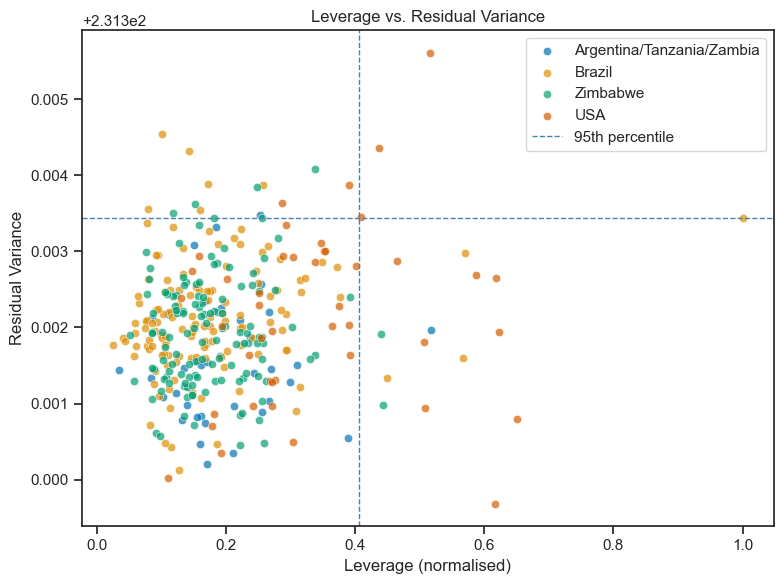

<Figure size 640x480 with 0 Axes>

In [ ]:
 #TODO: feil? -> denne er lagd av chat!
def plot_leverage_residuals(X, labels, color_map, ax, PCA_components=10, title = "Leverage vs. Residual Variance"):
    """
    Plots leverage vs. residual variance for outlier detection.
    
    Samples in the top-right 'danger zone' (high leverage, high residual)
    are the most likely outlier candidates.

    Args:
        X (np.ndarray): Spectral data matrix (samples x wavelengths).
        labels (pd.Series): Country labels for each sample.
        color_map (dict): Dictionary mapping country names to colors.
        PCA_components (int): Number of PCA components to use.
        ax: Matplotlib axes object. 
        title (str): Plot title.
    """
    pca = PCA(n_components=PCA_components)
    T = pca.fit_transform(X)       # scores (samples x components)
    P = pca.components_            # loadings (components x wavelengths)

    # Leverage: normalized Mahalanobis distance in PC space
    leverage = np.sum((T ** 2) / np.var(T, axis=0), axis=1)
    leverage = leverage / leverage.max()  # scale to [0, 1] 

    # Residual variance: how much of each sample is NOT explained by PCA
    X_reconstructed = T @ P
    residuals = X - X_reconstructed
    residual_variance = np.sum(residuals ** 2, axis=1)

    # Thresholds: 95th percentile #TODO: or based on std?
    lev_threshold = np.percentile(leverage, 95)
    res_threshold = np.percentile(residual_variance, 95)

    # Plot by country
    for country, color in color_map.items():
        mask = labels == country
        ax.scatter(leverage[mask], residual_variance[mask],
                   color=color, label=country, alpha=0.7,
                   edgecolors='white', linewidth=0.5)

    # Treshold lines
    ax.axvline(lev_threshold, color='steelblue', linestyle='--', linewidth=1, label='95th percentile')
    ax.axhline(res_threshold, color='steelblue', linestyle='--', linewidth=1)

    # # Label the quadrants
    # ax.text(0.97, 0.97, 'Danger zone', transform=ax.transAxes,
    #         ha='right', va='top', color='red', fontsize=9)
    # ax.text(0.03, 0.97, 'Not modelled well', transform=ax.transAxes,
    #         ha='left', va='top', color='gray', fontsize=9)
    # ax.text(0.97, 0.03, 'Modelled well,\nbut far away', transform=ax.transAxes,
    #         ha='right', va='bottom', color='gray', fontsize=9)

    ax.set_xlabel('Leverage (normalised)')
    ax.set_ylabel('Residual Variance')
    ax.set_title(title)
    ax.legend(loc='upper right')


# Plot for raw data
fig, ax = plt.subplots(figsize=(8, 6))
plot_leverage_residuals(X, countries, country_color_map, ax=ax)
plt.tight_layout()
plt.show()
sns.despine()

### 1.4 Split into training and testing data
Before doing preprocessing and modelling, the data is split into a testing set (30%) and validation set (70%).

In [ ]:
# To create the training set use:
from sklearn.model_selection import train_test_split

# Define the target variable (y)
# In this case, we are predicting the country of origin
y = nir_df["Country"]

# Split the data into Training (70%) and Testing (30%) sets
# We use 'stratify=y' to ensure each country is represented proportionally in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # The spectral matrix (347 rows)
    y,                  # The country labels
    test_size=0.3,     
    random_state=42,    
    stratify=y          # Maintains country distribution across splits
)

# Print the shapes to verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 242 samples
Testing set size:  105 samples


### 1.5 Preprocessing
Investigate and evaluate the impact of preprocessing using, for
instance, Multiplicative Scatter Correction (MSC), Standard Normal Variate (SNV), normalisation,
and/or derivatives to remove baseline shifts and scattering effects.

#### 1.5.1 Define functions for preprocessing methods

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

def mean_centering(spectra):
    """
    Mean Centering: Subtracts the mean of each variable (column) from the data.
    """
    return spectra - np.mean(spectra, axis=0)

def snv(spectra):
    """
    Standard Normal Variate: Normalizes each spectrum to its own mean and std.
    """
    mean = np.mean(spectra, axis=1, keepdims=True)
    std = np.std(spectra, axis=1, keepdims=True)
    return (spectra - mean) / std

def msc(spectra):
    """
    Multiplicative Scatter Correction: Regresses each spectrum against the mean spectrum.
    """
    # The reference is the average spectrum of the dataset
    reference = np.mean(spectra, axis=0)
    
    corrected = np.zeros_like(data)
    for i in range(spectra.shape[0]):
        # Perform linear regression: spectrum = a * reference + b
        poly = np.polyfit(reference, spectra[i, :], 1)
        # corrected = (raw - additive_bias) / multiplicative_scale
        corrected[i, :] = (spectra[i, :] - poly[1]) / poly[0]
    return corrected

# TODO: ikke riktig md tre forskjellige?
def sg_smooth(spectra, window_length=17, polyorder=2):
    """
    Savitzky-Golay Smoothing: Uses a 17-point window and 2nd-order poly.
    """
    return savgol_filter(spectra, window_length=window_length, polyorder=polyorder, deriv=0)

def sg_1d(spectra, window_length=17, polyorder=2):
    """
    First Derivative (SG): Removes baseline offsets.
    """
    return savgol_filter(spectra, window_length=window_length, polyorder=polyorder, deriv=1)

def sg_2d(spectra, window_length=17, polyorder=2):
    """
    Second Derivative (SG): Removes linear baseline trends.
    """
    return savgol_filter(spectra, window_length=window_length, polyorder=polyorder, deriv=2)

#### 1.5.2 Plots for comparing preproseccing methods 
Visual inspection of the NIR spectra and PCA scores plot of the preprocessed data will be used to evaluate the impact of preprocessing using different methods, to remove baseline shifts and scattering effects.

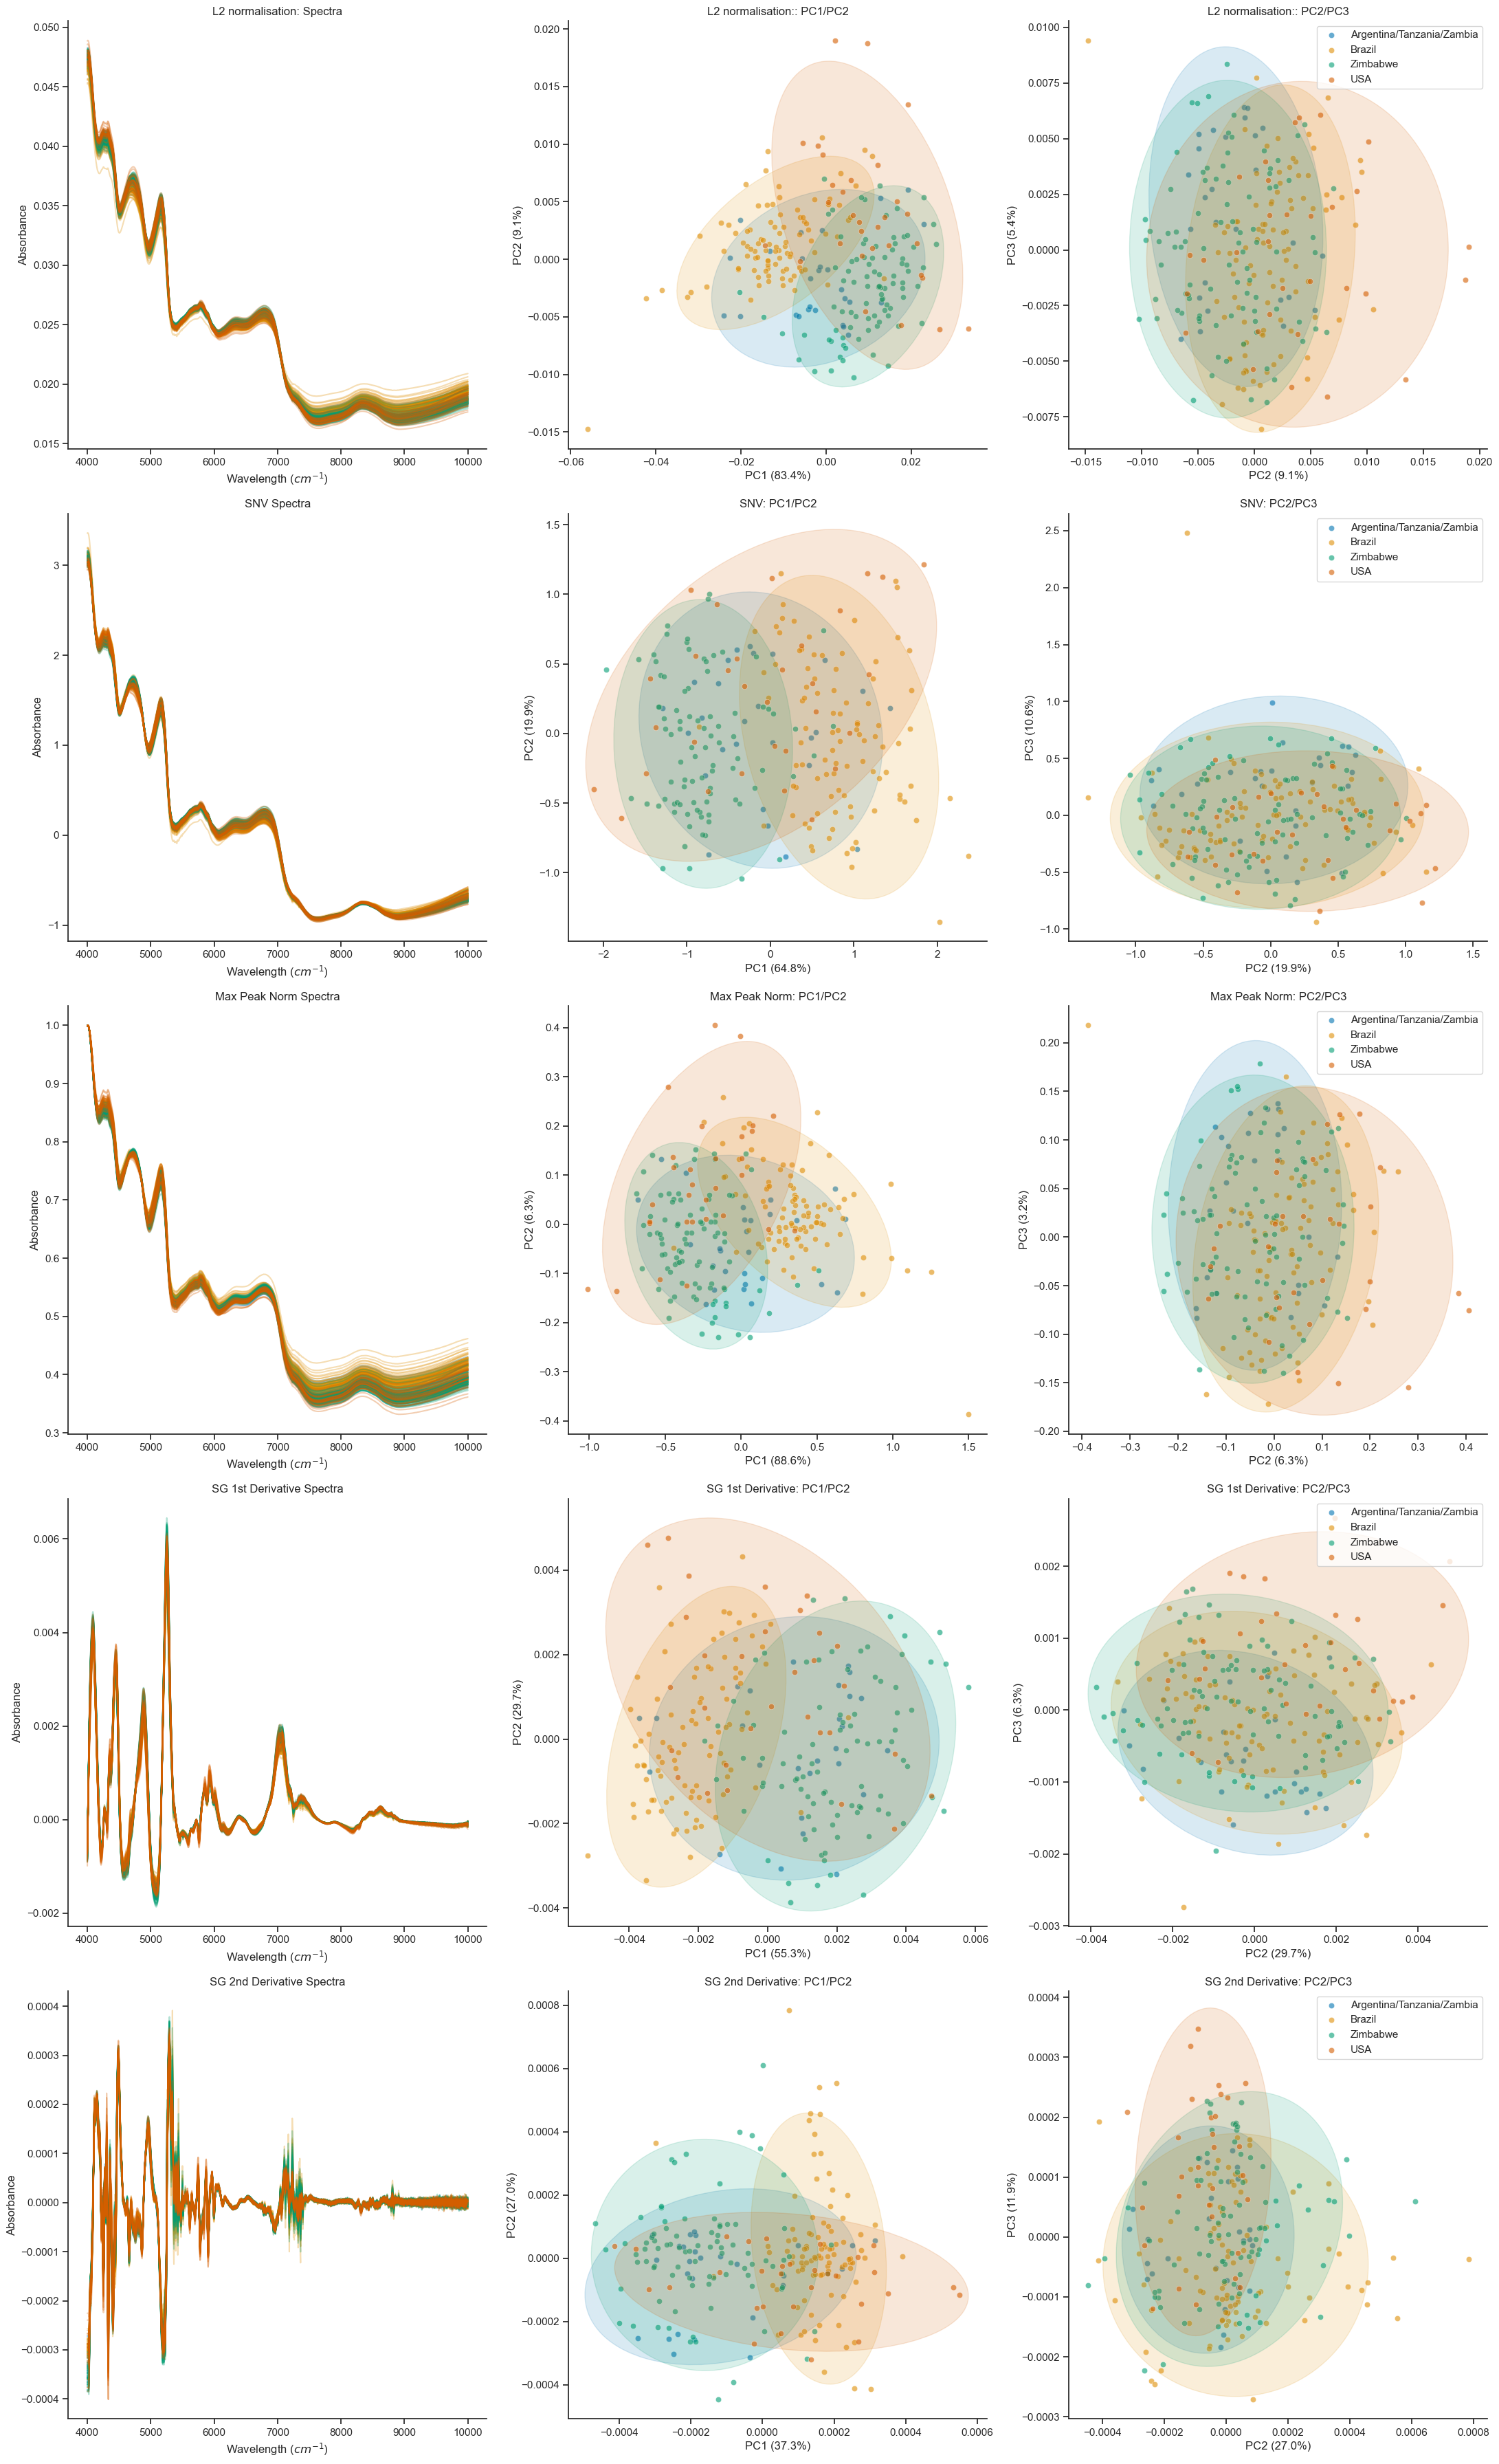

In [ ]:
X_l2 = normalise_l2(X_train)
X_max = normalise_max_peak(X_train)
X_snv = snv(X_train)
X_sg1 = sg1(X_train)
X_sg2 = sg2(X_train)

# Each method is stored as (label, preprocessed data) so the loop below
# can iterate without repeating code for every method.
methods = {
    "L2 normalisation:": X_l2,
    "SNV": X_snv,
    "Max Peak Norm": X_max,
    "SG 1st Derivative": X_sg1,
    "SG 2nd Derivative": X_sg2,
}

# One row per preprocessing method, three columns:
#   col 0 - raw preprocessed spectra
#   col 1 - PCA scores PC1 vs PC2
#   col 2 - PCA scores PC2 vs PC3 (legend shown here only, to avoid clutter)
fig, axes = plt.subplots(5, 3, figsize=(22, 36))

for i, (name, data) in enumerate(methods.items()):
    plot_nir_spectra(data, wavelengths, y_train, country_color_map,
                     axes[i, 0], title=f"{name} Spectra", show_legend=False)
    run_pca_and_plot_scores(data, y_train, country_color_map,
                            axes[i, 1], pcs=(1, 2), title=f"{name}: PC1/PC2", show_legend=False)
    run_pca_and_plot_scores(data, y_train, country_color_map,
                            axes[i, 2], pcs=(2, 3), title=f"{name}: PC2/PC3", show_legend=True)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

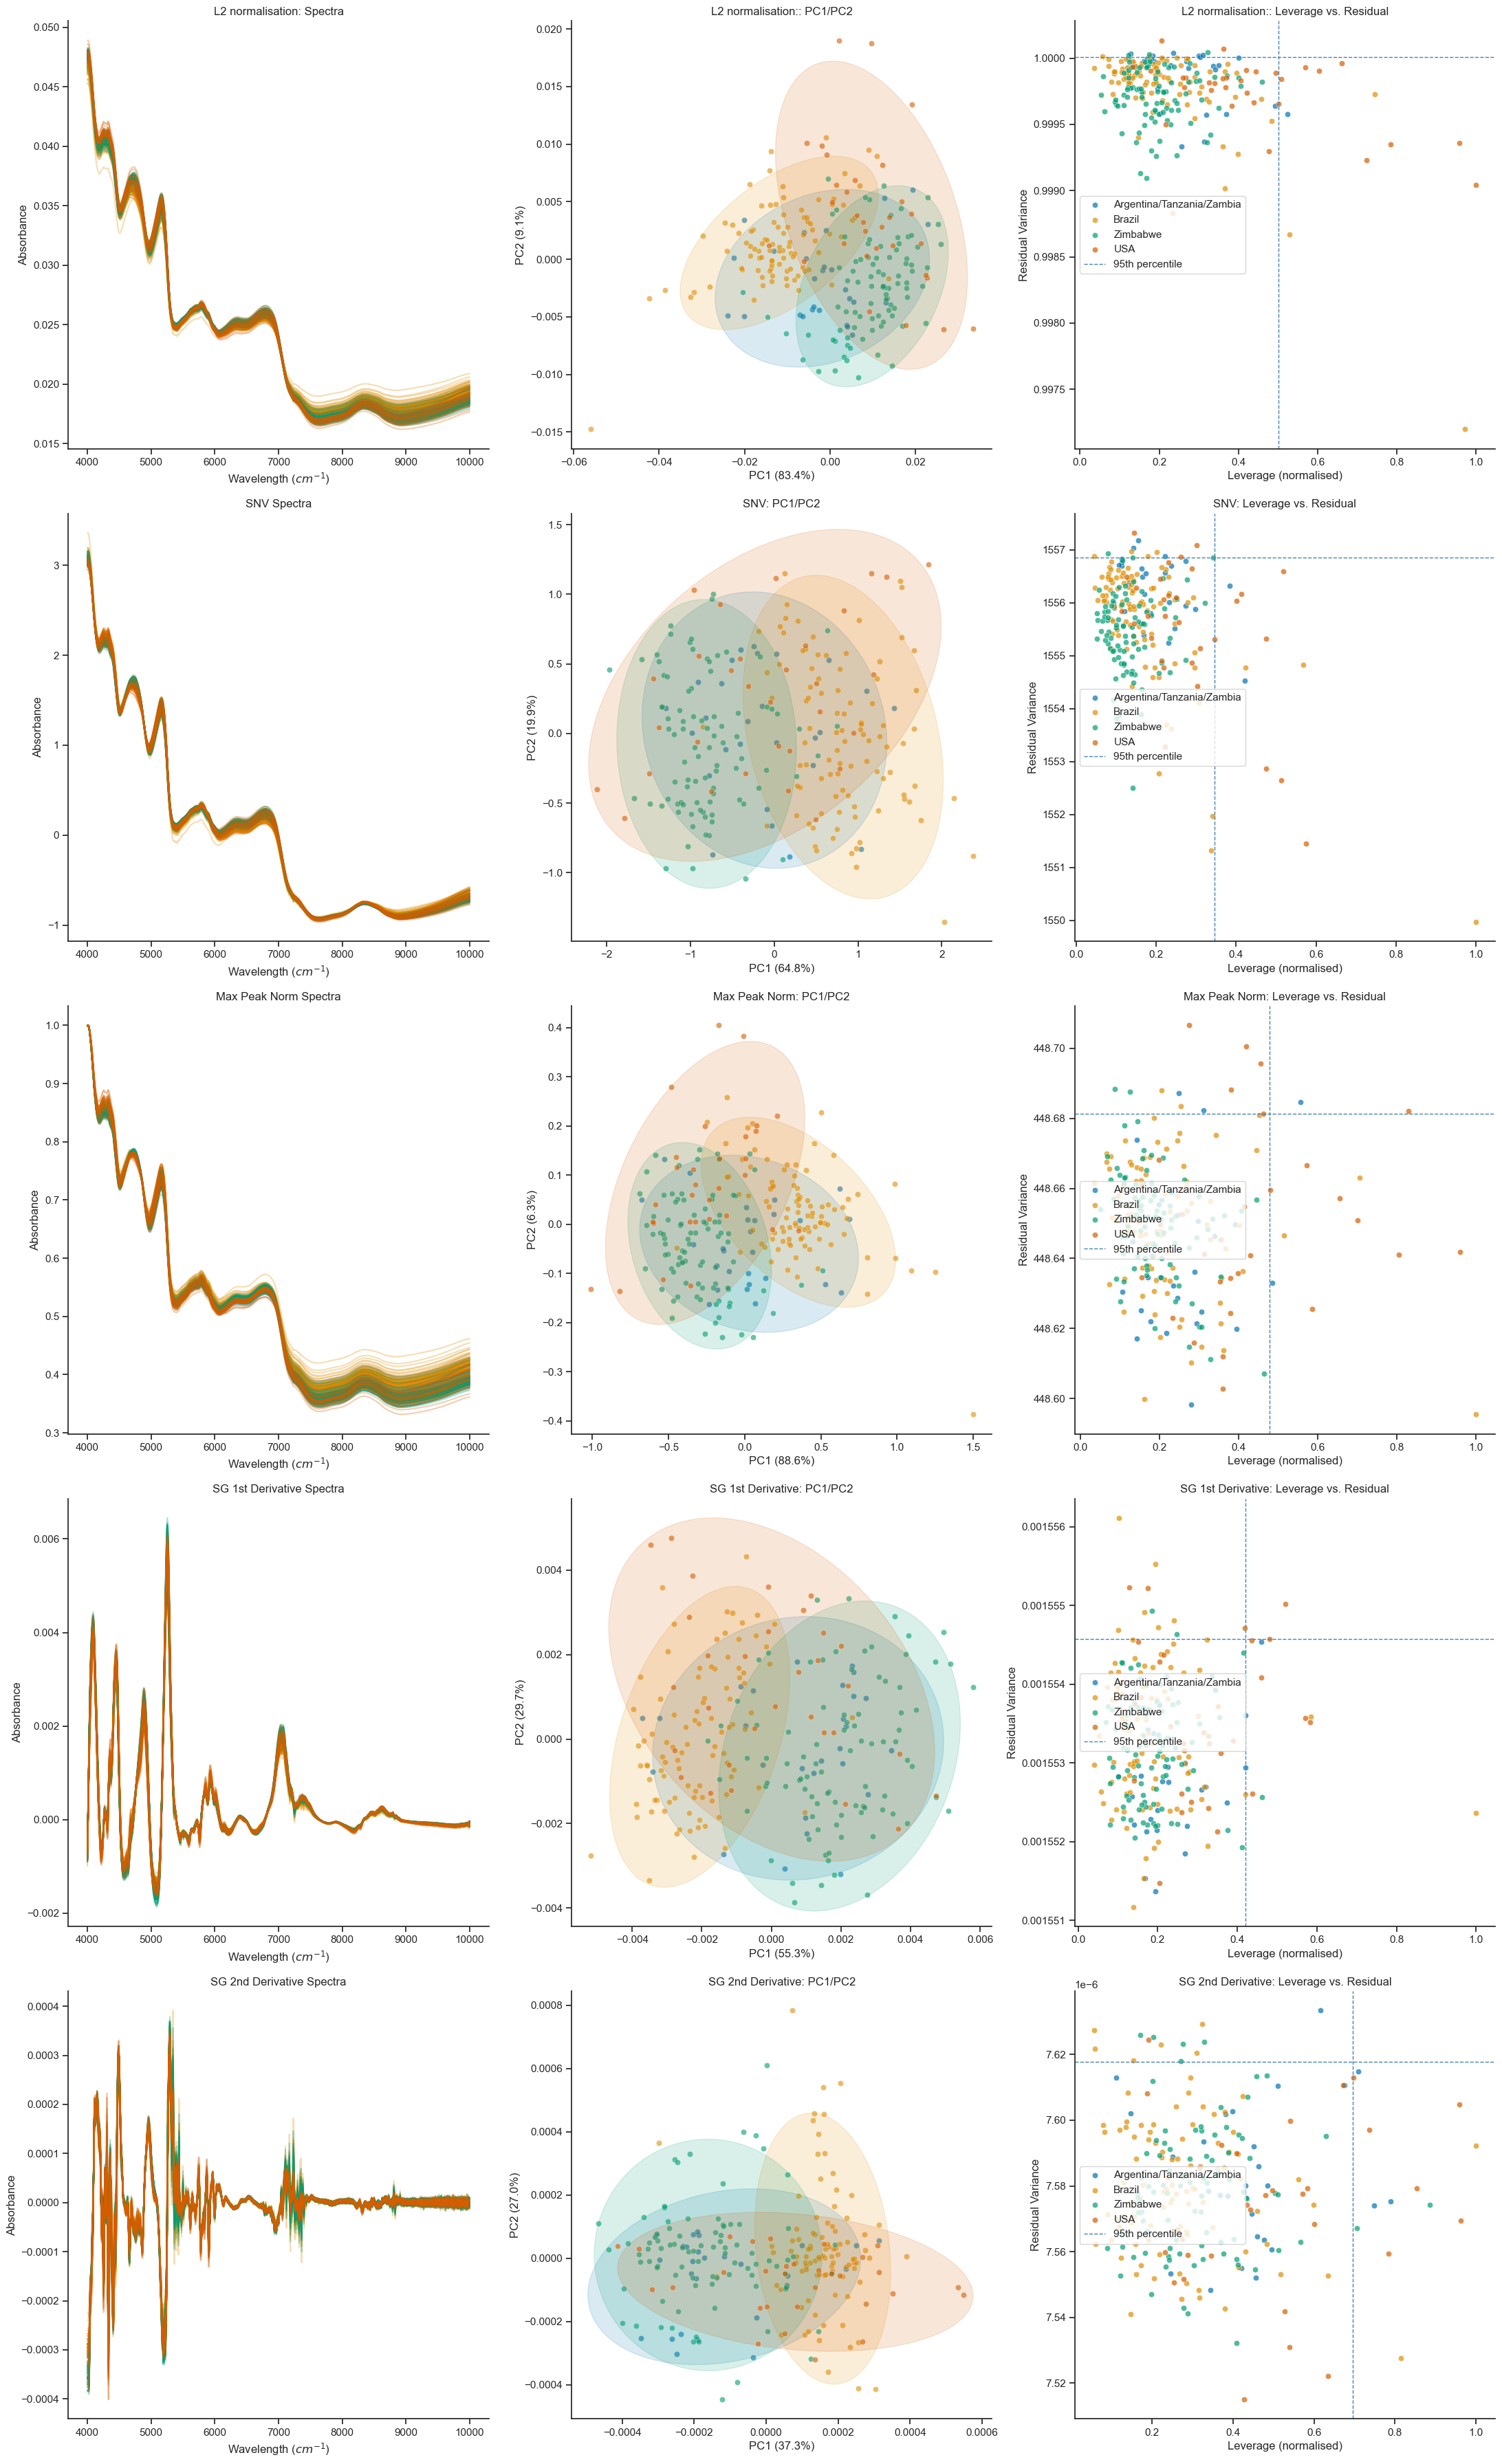

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(22, 36))

for i, (name, data) in enumerate(methods.items()):
    plot_nir_spectra(data, wavelengths, y_train, country_color_map,
                     axes[i, 0], title=f"{name} Spectra", show_legend=False)
    run_pca_and_plot_scores(data, y_train, country_color_map,
                            axes[i, 1], pcs=(1, 2), title=f"{name}: PC1/PC2", show_legend=False)
    plot_leverage_residuals(data, y_train, country_color_map,
                            ax=axes[i, 2], title=f"{name}: Leverage vs. Residual", n_components=10)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## Part 2 - Create classification models
Create at least two different classification models (with optimised hyperparameters, e.g., k in kNN) using two different classification methods (e.g., kNN and a random forest)

### 2.1 Define functions for making models
These will be fitted to the different preprocessed data and unprocessed data for comparison.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

def make_knn(X_train, y_train, k_range=range(1, 21), metric="accuracy"):
    """
    Trains a kNN classifier with optimised k using cross-validation.

    Args:
        X_train (np.ndarray): Training spectra.
        y_train (pd.Series): Training labels.
        k_range (range): Values of k to search over.

    Returns:
        best_knn (KNeighborsClassifier): Fitted model with best k.
        best_k (int): The optimal number of neighbours found. 
        best_score: The mean cross-validated score (using the specified metric) achieved with the optimal parameter
    """
    param_grid = {"n_neighbors": list(k_range)}
    grid = GridSearchCV(KNeighborsClassifier(), 
                        param_grid, 
                        scoring=metric) #TODO: which scoring metrics
    grid.fit(X_train, y_train)

    best_k = grid.best_params_["n_neighbors"]
    best_score = grid.best_score_
    best_knn = grid.best_estimator_
    
    print(f"Best k: {best_k}  |  CV {metric}: {best_score:.3f}")
    return best_knn, best_k, best_score


def make_random_forest(X_train, y_train, n_estimators_range=[50, 100, 200, 500], max_depth_range=range(1, 11), metric="accuracy"):
    """
    Trains a Random Forest classifier with optimised hyperparameters using cross-validation.

    Args:
        X_train (np.ndarray): Training spectra.
        y_train (pd.Series): Training labels.
        n_estimators_range (list): Number of trees to search over.
        max_depth_range (list): Tree depths to search over.

    Returns:
        best_param: Best max depth and n estimator
        best_rf (RandomForestClassifier): Fitted model with best hyperparameters.
        best_score = The mean cross-validated score (using the specified metric) achieved with the optimal parameters
    """
    param_grid = {
        "n_estimators": n_estimators_range,
        "max_depth": max_depth_range
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        param_grid, 
        scoring=metric,
        )
    grid.fit(X_train, y_train)

    best_param = grid.best_params_
    best_score = grid.best_score_
    best_rf = grid.best_estimator_

    print(f"Best params: {best_param}  |  CV accuracy: {best_score:.3f}")
    return best_param, best_rf, best_rf

### 2.2 Train models
The knn and random forest model is trained using the training data.
Both the raw training data, and the preprocessed training data is used.

In [ ]:
# 1. Preprocess Training Data
methods = { #TODO msc!!
    "Raw": X_train,
    "L2": normalise_l2(X_train),
    "Max Peak": normalise_max_peak(X_train),
    "SNV": snv(X_train),
    "SG1": sg1(X_train),
    "SG2": sg2(X_train)
}

# 2. Preprocess Test Data (using the same functions)
methods_test = {
    "Raw": X_test,
    "L2": normalise_l2(X_test),
    "Max Peak": normalise_max_peak(X_test),
    "SNV": snv(X_test),
    "SG1": sg1(X_test),
    "SG2": sg2(X_test)
}

In [ ]:
# Dictionaries to store results
knn_results = {}
rf_results = {}

for name, X_train_pre in methods.items():
    print(f"Optimising models for: {name}...")
    
    # Train KNN (returns best_knn, best_k, best_score)
    knn_model, k, k_score = make_knn(X_train_pre, y_train, metric="balanced_accuracy")
    knn_results[name] = {"model": knn_model, "k": k, "cv_score": k_score}
    
    # Train RF (returns best_param, best_rf, best_score)
    rf_params, rf_model, r_score = make_random_forest(X_train_pre, y_train, metric="balanced_accuracy")
    rf_results[name] = {"model": rf_model, "params": rf_params, "cv_score": r_score}
    
    print("-" * 30)

Optimising models for: Raw...
Best k: 4  |  CV balanced_accuracy: 0.670
Best params: {'max_depth': 10, 'n_estimators': 100}  |  CV accuracy: 0.639
------------------------------
Optimising models for: L2...
Best k: 6  |  CV balanced_accuracy: 0.670
Best params: {'max_depth': 7, 'n_estimators': 100}  |  CV accuracy: 0.734
------------------------------
Optimising models for: Max Peak...
Best k: 4  |  CV balanced_accuracy: 0.643
Best params: {'max_depth': 5, 'n_estimators': 50}  |  CV accuracy: 0.719
------------------------------
Optimising models for: SNV...
Best k: 1  |  CV balanced_accuracy: 0.631
Best params: {'max_depth': 6, 'n_estimators': 500}  |  CV accuracy: 0.758
------------------------------
Optimising models for: SG1...
Best k: 1  |  CV balanced_accuracy: 0.715
Best params: {'max_depth': 6, 'n_estimators': 200}  |  CV accuracy: 0.780
------------------------------
Optimising models for: SG2...
Best k: 1  |  CV balanced_accuracy: 0.791
Best params: {'max_depth': 5, 'n_estima

In [ ]:
from sklearn.metrics import balanced_accuracy_score
import pandas as pd

summary = []

for name in methods.keys():
    # Evaluate KNN
    y_pred_knn = knn_results[name]["model"].predict(methods_test[name])
    test_acc_knn = balanced_accuracy_score(y_test, y_pred_knn)
    
    # Evaluate RF
    y_pred_rf = rf_results[name]["model"].predict(methods_test[name])
    test_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
    
    summary.append({
        "Method": name,
        "KNN CV": knn_results[name]["cv_score"],
        "KNN Test": test_acc_knn,
        "RF CV": rf_results[name]["cv_score"],
        "RF Test": test_acc_rf
    })

results_df = pd.DataFrame(summary)
print(results_df.round(3))

     Method  KNN CV  KNN Test  \
0       Raw   0.670     0.601   
1        L2   0.670     0.612   
2  Max Peak   0.643     0.613   
3       SNV   0.631     0.643   
4       SG1   0.715     0.760   
5       SG2   0.791     0.852   

                                               RF CV  RF Test  
0  (DecisionTreeClassifier(max_depth=10, max_feat...    0.674  
1  (DecisionTreeClassifier(max_depth=7, max_featu...    0.698  
2  (DecisionTreeClassifier(max_depth=5, max_featu...    0.581  
3  (DecisionTreeClassifier(max_depth=6, max_featu...    0.747  
4  (DecisionTreeClassifier(max_depth=6, max_featu...    0.764  
5  (DecisionTreeClassifier(max_depth=5, max_featu...    0.774  


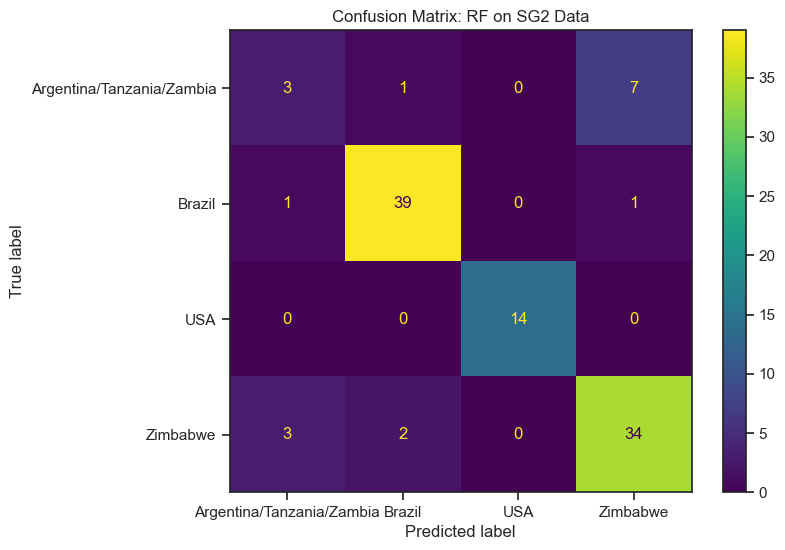

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Find best performer for RF
best_method_name = results_df.loc[results_df['RF Test'].idxmax(), 'Method']
best_model = rf_results[best_method_name]["model"]

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model, 
    methods_test[best_method_name], 
    y_test, 
    cmap='viridis',
    ax=ax
)
ax.set_title(f"Confusion Matrix: RF on {best_method_name} Data")
plt.show()

## Part 3 - Evaluate and compare
Evaluate and compare the performance of your classification models using the accuracy and F1-
score. Show the confusion matrices of the two models. Are you far away from the accuracy of 0.8
achieved by Chen et al. [1]?

Either do with all of the different preprocessed data, 
or with only one that was selected as the best,
or focus on the best one, for confusion matrix etc to compare the different models, but make a table with metrics for all to compare

### 3.1 Define functions for calculating metrics and plotting confusion matrix

### 3.2 Create table of metrics and figure of confusion matrices

## Part 4 - Interpretation
Interpret your classification models. For instance, can you identify spectral regions unique to specific regions?